# Anomaly Detection — Isolation Forest, Autoencoder, LOF, and One-Class SVM

**Author:** Shivani Bokka
**Dataset:** Credit Card Fraud Detection (ULB / Kaggle) — 284,807 real European card transactions, 492 frauds (0.17%)
**Goal:** Detect rare anomalies using both statistical and neural approaches

---

## What Is This Notebook About?

This notebook is a **complete, practical guide to anomaly detection** — the task of finding the rare, unusual data points hiding inside a mostly-normal dataset. Think of it as finding the needle in a haystack, except the haystack is 99.8% normal transactions and the needle is a fraudulent one.

Each section explains the core idea in plain English before diving into the code. We cover four very different approaches — from classic forest-based methods to deep learning autoencoders — and compare them head-to-head at the end.

---

## Models Covered

| # | Method | Core Idea |
|---|--------|-----------|
| 1 | Isolation Forest | Anomalies are isolated faster with fewer random splits |
| 2 | Local Outlier Factor (LOF) | Anomalies are points far less dense than their neighbors |
| 3 | One-Class SVM | Learns a boundary around normal data; outliers fall outside it |
| 4 | Autoencoder (PyTorch) | Trained only on normal data; anomalies have high reconstruction error |

We also add two more: **Elliptic Envelope** (a Gaussian baseline) and **novelty-mode LOF** (train on clean data, score new points).

---

## Why Is Anomaly Detection Hard?

Three things make this problem uniquely challenging:

1. **Extreme class imbalance** — In fraud detection, 99%+ of data is normal. Standard accuracy is meaningless (a model that always predicts "normal" scores 99.8% accuracy but catches zero fraud).
2. **Often no labels** — In real deployments, you frequently don't have a labeled set of known frauds to train on. You have to work unsupervised.
3. **The rare class keeps changing** — Fraud patterns evolve. A model trained on last year's fraud may miss this year's new techniques.

---


## Section 1 — Imports and Setup

Before anything else, we import everything we'll need throughout this notebook.

- **numpy / pandas** — data manipulation
- **matplotlib / seaborn** — visualization
- **sklearn** — Isolation Forest, LOF, One-Class SVM, and dataset generation
- **torch / torch.nn** — PyTorch for the Autoencoder
- **time** — measuring training duration for the final comparison table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Display and style settings
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully!
PyTorch version: 2.5.1+cu121


---

## Section 2 — What Is Anomaly Detection?

### The Core Idea

Anomaly detection is the task of **identifying data points that are significantly different from the majority of the data**. These unusual points — called anomalies or outliers — often signal something important: a fraud attempt, a failing machine part, a rare disease event, or a network intrusion.

Unlike classification, anomaly detection is often **unsupervised** — you rarely have a labeled collection of "known anomalies" to train on. Instead, you learn what "normal" looks like, and flag anything that deviates significantly.

---

### Types of Anomalies

There are three main types:

| Type | Description | Example |
|------|-------------|----------|
| **Point Anomaly** | A single observation is unusual relative to the rest | One transaction of $50,000 in an account that normally sees $200 transactions |
| **Contextual Anomaly** | A data point is normal globally but unusual in context | 80°F temperature in July (normal) vs. 80°F in December in Minnesota (anomaly) |
| **Collective Anomaly** | A sequence of data points is anomalous together, though each is individually normal | Many small rapid transactions just below a fraud detection threshold — normal individually, but suspicious as a group |

---

### Real-World Uses

- **Fraud detection** — flag suspicious credit card transactions in real time
- **Network intrusion detection** — identify unusual login patterns or data transfers
- **Manufacturing defects** — catch defective parts in a production line before they ship
- **Medical outliers** — identify patients with abnormal lab values that might indicate a rare condition
- **Predictive maintenance** — detect anomalous sensor readings before a machine fails

---

### Load the Dataset

We use the **[Credit Card Fraud Detection](https://www.openml.org/d/42175)** dataset: 284,807 real
credit-card transactions made by European cardholders in September 2013, of which only **492 are fraud
(0.17%)** — genuinely extreme imbalance, not a simulated one. For privacy, 28 of the features (`V1`–`V28`)
are anonymized principal components; the two untouched features are `Time` and `Amount`. We use `V1`–`V28`
plus `Amount` (dropping `Time`).

To keep the notebook fast we keep **all 492 frauds** and a random 16,000 normal transactions — preserving a
realistic ~3% fraud rate while making One-Class SVM and the autoencoder tractable.


In [2]:
# Load the REAL Credit Card Fraud dataset (284,807 transactions, 492 frauds)
from sklearn.datasets import fetch_openml

raw  = fetch_openml('CreditCardFraudDetection', version=1, as_frame=True, parser='auto')
full = raw.frame.copy()
full['Class'] = full['Class'].astype(int)

# Feature set: 28 anonymized PCA components (V1–V28) + transaction Amount (drop Time)
feature_names = [c for c in full.columns if c not in ('Time', 'Class')]
n_features    = len(feature_names)

# Subsample: keep ALL frauds + 16,000 random normals -> realistic ~3% rate, fast to train
fraud_df  = full[full['Class'] == 1]
normal_df = full[full['Class'] == 0].sample(n=16000, random_state=RANDOM_STATE)
df = (pd.concat([fraud_df, normal_df])
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
        .rename(columns={'Class': 'label'}))

print("Dataset shape:", df[feature_names + ['label']].shape)
print(f"(Subsampled from {len(full):,} real transactions — all {len(fraud_df)} frauds kept)")
print(f"Using {n_features} features: V1–V28 + Amount")
print("\nClass distribution:")
print(df['label'].value_counts())
print(f"\nFraud rate: {df['label'].mean() * 100:.2f}%")
print("\nFirst 5 rows:")
df[feature_names + ['label']].head()


Dataset shape: (16492, 30)
(Subsampled from 284,807 real transactions — all 492 frauds kept)
Using 29 features: V1–V28 + Amount

Class distribution:
label
0    16000
1      492
Name: count, dtype: int64

Fraud rate: 2.98%

First 5 rows:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,label
0,-0.5143,0.5449,1.6162,-0.6809,0.0964,-0.5260,0.2936,-0.0453,-0.2558,-0.5860,...,-0.0059,-0.0075,-0.0415,0.1663,-0.3657,0.8781,-0.1445,0.0206,6.7200,0
1,2.0211,-0.1111,-3.2293,-0.5866,2.7039,2.9955,-0.3614,0.7215,0.4346,-0.5023,...,0.1943,0.5909,0.0076,0.6285,0.2853,-0.0817,0.0157,-0.0335,14.8900,0
2,-0.1870,-0.5739,1.5550,-2.6552,-0.9856,-0.0512,-0.6906,0.2372,-2.0271,1.0137,...,0.0237,0.2951,-0.2059,-0.5723,-0.2953,-0.2546,0.1382,0.1207,12.0000,0
3,1.9098,-0.1421,-1.1215,0.5558,0.1401,-0.6430,0.0686,-0.3335,1.3441,-0.0680,...,0.0749,0.4289,-0.0017,-0.3256,-0.0229,0.3367,-0.0968,-0.0663,73.9800,0
4,1.9991,-0.4487,-0.4834,0.3750,-0.4999,-0.0923,-0.6857,0.0663,1.5295,-0.1613,...,0.1702,0.6923,0.1343,0.5898,-0.0639,-0.2354,0.0340,-0.0321,9.9900,0


In [3]:
# Split into train and test
X_data = df[feature_names].values
y_labels = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.3, random_state=RANDOM_STATE, stratify=y_labels
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}  |  Test size: {X_test.shape}")
print(f"Train fraud count: {y_train.sum()}  |  Test fraud count: {y_test.sum()}")

Train size: (11544, 29)  |  Test size: (4948, 29)
Train fraud count: 344  |  Test fraud count: 148


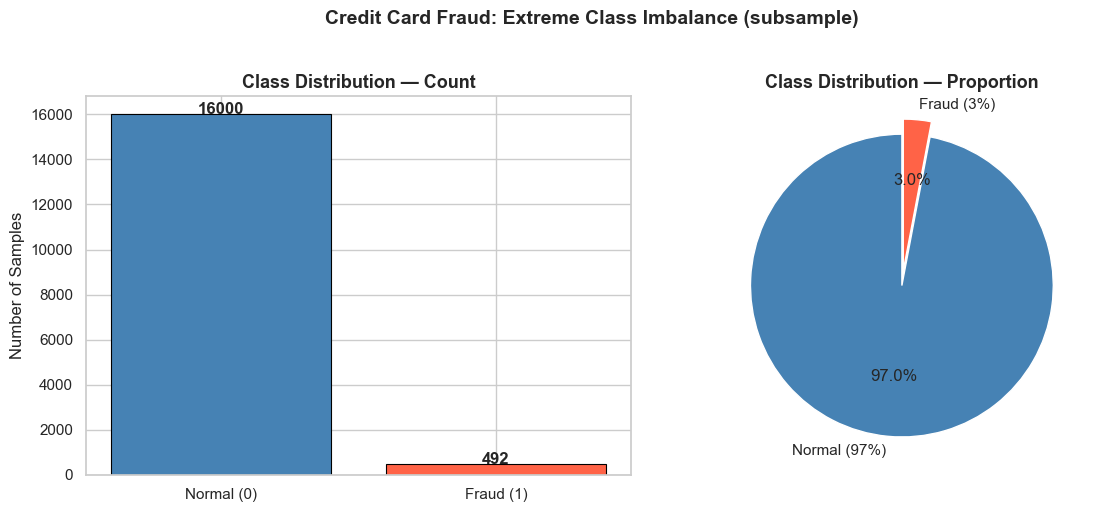

In [4]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = pd.Series(y_labels).value_counts().sort_index()
colors = ['steelblue', 'tomato']
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=['Normal (97%)', 'Fraud (3%)'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.1)
)
axes[1].set_title('Class Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Credit Card Fraud: Extreme Class Imbalance (subsample)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### How to Read This Chart: Class Distribution

This pair of charts shows the **extreme imbalance** in our dataset.

- **Left (bar chart):** The height of each bar is the count of samples. The Normal bar towers over the Fraud bar — roughly 970 normal vs. 30 fraud.
- **Right (pie chart):** The tiny red slice is the fraud class. The exploded slice makes the minority class visible — otherwise it would be nearly invisible.

**Why this matters:**
- A naive classifier that always predicts "Normal" would achieve **97% accuracy** — but that's completely useless for fraud detection.
- This is why we use **Precision, Recall, F1, and AUC-PR** as metrics — not accuracy.
- Precision asks: "Of all the transactions I flagged as fraud, how many actually were?"
- Recall asks: "Of all the real frauds, how many did I catch?"
- In fraud detection, **missing a fraud (low recall) is usually more costly** than a false alarm (low precision).

---

## Section 3 — Isolation Forest

### The Core Idea

**Isolation Forest** works on a beautifully simple insight: anomalies are different from normal points, so they are **easier to isolate**.

The algorithm builds a forest of random decision trees. At each split, it randomly selects a feature and a split value. The key observation is:

> **Anomalies require fewer splits to isolate** because they are far from the cluster of normal points. Normal points are surrounded by other normal points and need many splits before they're alone in a leaf node.

Think of it like this: if you're trying to find Waldo in a crowd, and Waldo is standing alone in the corner, you can isolate him with just one or two fences. But to isolate someone standing in the middle of the crowd, you'd need dozens of fences.

---

### ASCII Diagram: How Isolation Works

```
NORMAL POINT (buried in the crowd):
                                      
  Split 1: ─────────────────────────────
  Split 2:           ──────────────
  Split 3:              ───────
  Split 4:               ────              ← Still not isolated!
  Split 5:               ──
  Split 6:               ─                 ← Finally isolated. Many splits needed.

ANOMALY POINT (out in the open):

  Split 1: ─────────────────────────────  ← Already isolated after 1 split!

  Short path length = anomaly
  Long path length  = normal point
```

The **anomaly score** is based on the average path length across all trees. Shorter path = more anomalous.

---

### Strengths of Isolation Forest

- **Fast:** linear time complexity, scales to very large datasets
- **No distance metric needed:** doesn't suffer from the curse of dimensionality the way LOF does
- **Works well in high dimensions:** random partitioning is robust even with many features
- **Doesn't require labeled data:** fully unsupervised

In [5]:
# Train Isolation Forest
t0 = time.time()
iso_forest = IsolationForest(
    contamination=0.03,
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_scaled)
t_iso = time.time() - t0

# Predict on test set
# IsolationForest returns -1 for anomaly, +1 for normal
# We convert to 1 (anomaly) and 0 (normal) to match our labels
iso_raw_preds = iso_forest.predict(X_test_scaled)
iso_preds = np.where(iso_raw_preds == -1, 1, 0)  # -1 -> anomaly -> 1

# Anomaly scores (more negative = more anomalous)
iso_scores = iso_forest.decision_function(X_test_scaled)

prec_iso = precision_score(y_test, iso_preds, zero_division=0)
rec_iso  = recall_score(y_test, iso_preds, zero_division=0)
f1_iso   = f1_score(y_test, iso_preds, zero_division=0)
# For AUC-PR: we need a score where higher = more anomalous
iso_scores_for_pr = -iso_scores  # flip sign: higher now means more anomalous
auc_pr_iso = average_precision_score(y_test, iso_scores_for_pr)

print("--- Isolation Forest Results ---")
print(f"  Precision : {prec_iso:.4f}")
print(f"  Recall    : {rec_iso:.4f}")
print(f"  F1 Score  : {f1_iso:.4f}")
print(f"  AUC-PR    : {auc_pr_iso:.4f}")
print(f"  Train time: {t_iso:.3f}s")

--- Isolation Forest Results ---
  Precision : 0.5763
  Recall    : 0.6892
  F1 Score  : 0.6277
  AUC-PR    : 0.6721
  Train time: 0.681s


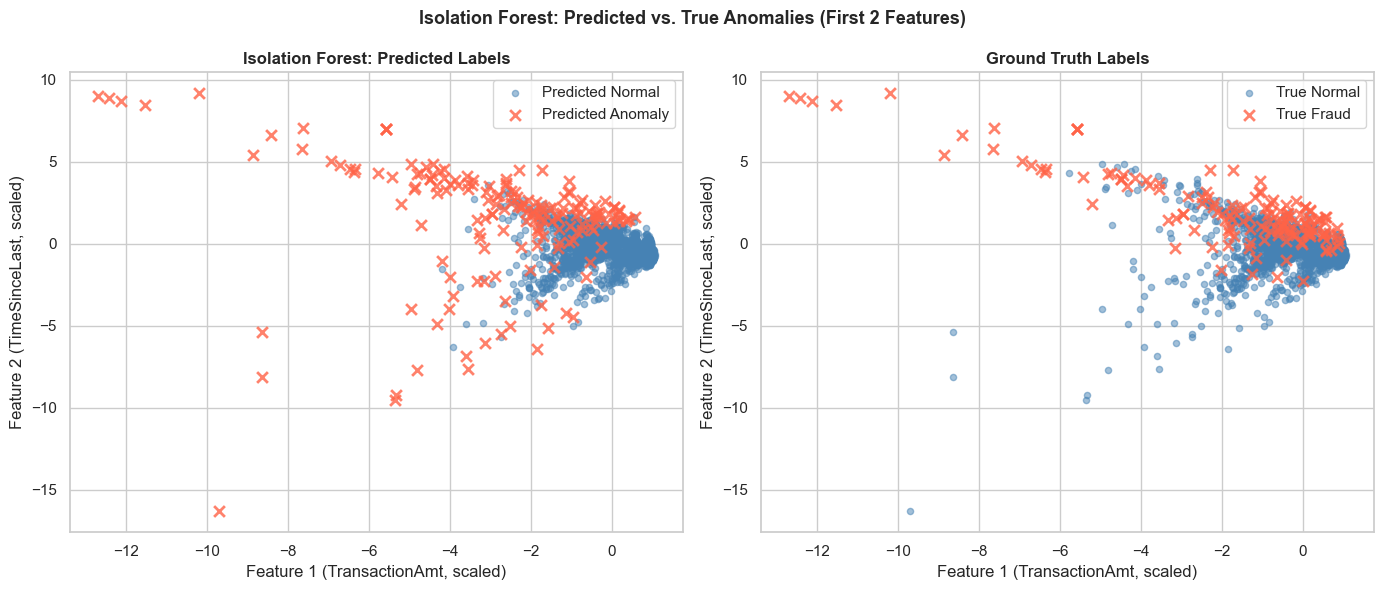

In [6]:
# Scatter plot: first two features, colored by predicted anomaly vs. normal
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Predicted labels
normal_mask = iso_preds == 0
anomaly_mask = iso_preds == 1

axes[0].scatter(
    X_test_scaled[normal_mask, 0], X_test_scaled[normal_mask, 1],
    c='steelblue', alpha=0.5, s=20, label='Predicted Normal'
)
axes[0].scatter(
    X_test_scaled[anomaly_mask, 0], X_test_scaled[anomaly_mask, 1],
    c='tomato', alpha=0.8, s=60, marker='x', linewidths=2, label='Predicted Anomaly'
)
axes[0].set_title('Isolation Forest: Predicted Labels', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1 (TransactionAmt, scaled)')
axes[0].set_ylabel('Feature 2 (TimeSinceLast, scaled)')
axes[0].legend()

# Right: True labels
true_normal = y_test == 0
true_fraud  = y_test == 1

axes[1].scatter(
    X_test_scaled[true_normal, 0], X_test_scaled[true_normal, 1],
    c='steelblue', alpha=0.5, s=20, label='True Normal'
)
axes[1].scatter(
    X_test_scaled[true_fraud, 0], X_test_scaled[true_fraud, 1],
    c='tomato', alpha=0.8, s=60, marker='x', linewidths=2, label='True Fraud'
)
axes[1].set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1 (TransactionAmt, scaled)')
axes[1].set_ylabel('Feature 2 (TimeSinceLast, scaled)')
axes[1].legend()

plt.suptitle('Isolation Forest: Predicted vs. True Anomalies (First 2 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Isolation Forest Scatter

This side-by-side scatter plot uses only the **first two features** of the dataset for visualization (the model was trained on all 10).

- **Blue dots** = points predicted as (or labeled) Normal.
- **Red X marks** = points predicted as (or labeled) Anomalous/Fraud.
- **Left panel:** What Isolation Forest predicted.
- **Right panel:** The ground truth.

**What to look for:**
- Ideally, the red X marks in both panels would be in the same positions — perfect alignment means no errors.
- Red X marks in the left panel that don't appear in the right panel are **false positives** (normal transactions flagged as fraud).
- Positions in the right panel with red X marks that have no red X in the left panel are **missed frauds** (false negatives).
- Because only 2 of 10 features are shown, some separation you'd see in the full feature space is compressed here — the model actually uses all 10 features.

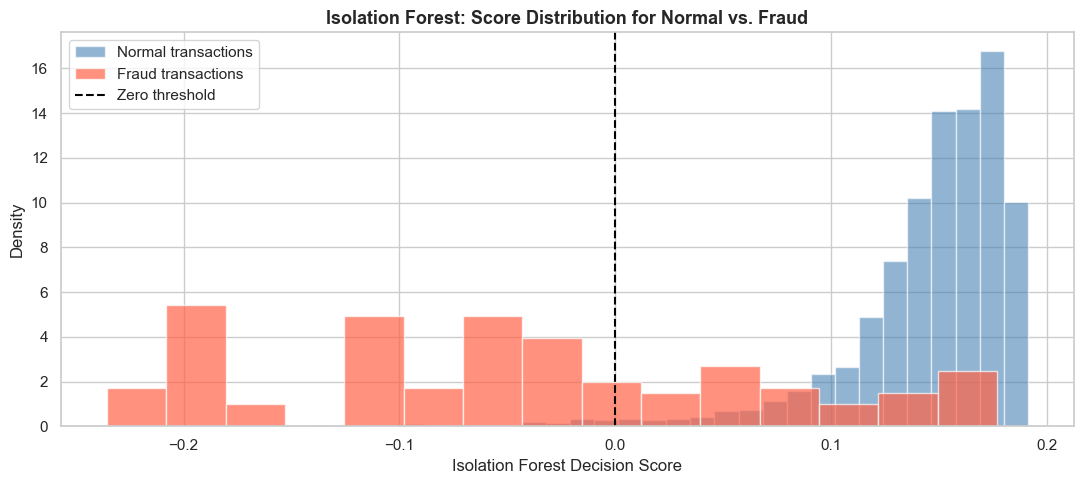

Normal score — mean: 0.1455,  std: 0.0400
Fraud  score — mean: -0.0450,  std: 0.1123


In [7]:
# Anomaly score distribution: fraud vs. normal separately
fraud_scores  = iso_scores[y_test == 1]
normal_scores = iso_scores[y_test == 0]

plt.figure(figsize=(11, 5))
plt.hist(normal_scores, bins=30, alpha=0.6, color='steelblue', label='Normal transactions', density=True)
plt.hist(fraud_scores,  bins=15, alpha=0.7, color='tomato',    label='Fraud transactions',  density=True)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Zero threshold')
plt.xlabel('Isolation Forest Decision Score')
plt.ylabel('Density')
plt.title('Isolation Forest: Score Distribution for Normal vs. Fraud', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Normal score — mean: {normal_scores.mean():.4f},  std: {normal_scores.std():.4f}")
print(f"Fraud  score — mean: {fraud_scores.mean():.4f},  std: {fraud_scores.std():.4f}")

### How to Read This Chart: Isolation Forest Scores

This is a **density histogram** of the anomaly scores assigned by Isolation Forest, split by true class.

- **The x-axis** is the raw decision score from `decision_function()`. **More negative = more anomalous**. A score near 0 or positive = likely normal; a score of -0.1 or lower = likely an anomaly.
- **Blue distribution** = normal transactions. You expect this to peak toward the right (less negative), meaning the model considers them safe.
- **Red distribution** = fraud transactions. You expect this to peak toward the left (more negative), meaning the model considers them suspicious.
- **The dashed black line at 0** is the decision boundary when `contamination` sets the threshold.

**What good separation looks like:**
- The blue and red peaks should be in **different parts of the x-axis** — blue to the right, red to the left.
- Overlap in the middle = uncertain zone where the model makes mistakes.
- Perfect separation = no overlap, every fraud gets a negative score, every normal transaction gets a positive score.

> **Key insight:** The anomaly score is a continuous value — by adjusting the threshold, you trade off precision vs. recall. This is explored in Section 8.

---

## Section 4 — Contamination Parameter Tuning

### What Is the Contamination Parameter?

The `contamination` parameter in Isolation Forest tells the model **what fraction of the training data to treat as anomalies** when setting the decision threshold. It does not change how the trees are built — it only shifts where the decision boundary is drawn.

Think of it as your **prior belief about the fraud rate in your data:**
- Set it too **low** (e.g., 0.01): the model only flags the most extreme outliers, missing many real frauds.
- Set it too **high** (e.g., 0.20): the model flags too many normal transactions as fraud — high false positive rate.
- **Best practice:** set it to your domain estimate of the true anomaly rate.

> In practice, you can calibrate it using a small labeled validation set, historical fraud rates, or business cost analysis.

In [8]:
# Tune contamination parameter
contamination_values = [0.01, 0.03, 0.05, 0.10, 0.20]
contam_results = []

for c in contamination_values:
    clf = IsolationForest(
        contamination=c,
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    clf.fit(X_train_scaled)
    preds_raw = clf.predict(X_test_scaled)
    preds = np.where(preds_raw == -1, 1, 0)

    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1   = f1_score(y_test, preds, zero_division=0)
    flagged = preds.sum()

    contam_results.append({
        'contamination': c,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'flagged': flagged
    })
    print(f"contamination={c:.2f} | flagged={flagged:3d} | prec={prec:.3f} | recall={rec:.3f} | f1={f1:.3f}")

contam_df = pd.DataFrame(contam_results)

contamination=0.01 | flagged= 61 | prec=0.869 | recall=0.358 | f1=0.507


contamination=0.03 | flagged=177 | prec=0.576 | recall=0.689 | f1=0.628


contamination=0.05 | flagged=261 | prec=0.437 | recall=0.770 | f1=0.557


contamination=0.10 | flagged=548 | prec=0.235 | recall=0.872 | f1=0.371


contamination=0.20 | flagged=1030 | prec=0.128 | recall=0.892 | f1=0.224


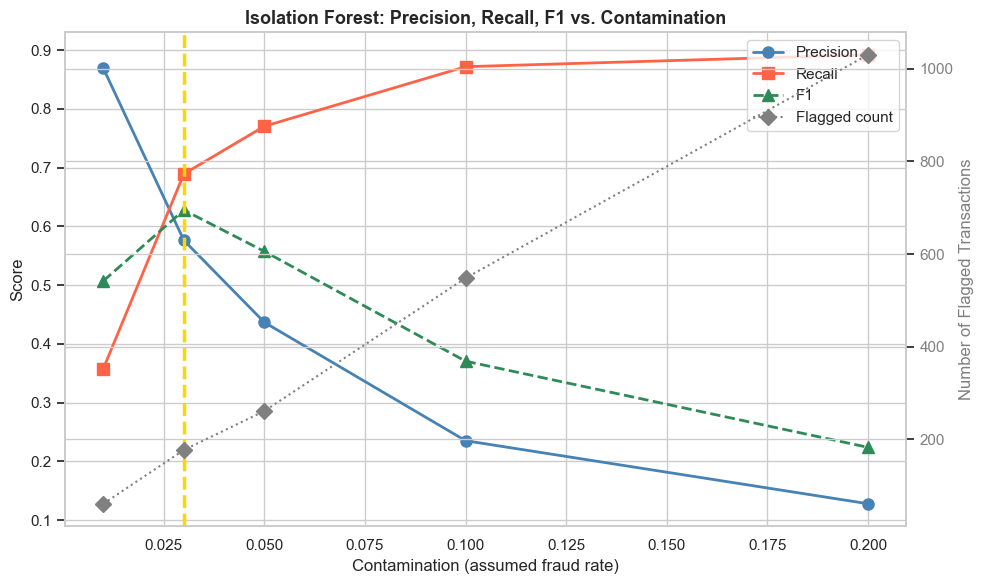

In [9]:
# Plot precision and recall vs contamination
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Contamination (assumed fraud rate)', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)

line1, = ax1.plot(contam_df['contamination'], contam_df['precision'],
                  color='steelblue', marker='o', linewidth=2, markersize=8, label='Precision')
line2, = ax1.plot(contam_df['contamination'], contam_df['recall'],
                  color='tomato', marker='s', linewidth=2, markersize=8, label='Recall')
line3, = ax1.plot(contam_df['contamination'], contam_df['f1'],
                  color='seagreen', marker='^', linewidth=2, markersize=8, label='F1', linestyle='--')

ax2 = ax1.twinx()
ax2.set_ylabel('Number of Flagged Transactions', fontsize=12, color='gray')
line4, = ax2.plot(contam_df['contamination'], contam_df['flagged'],
                  color='gray', marker='D', linewidth=1.5, markersize=8, linestyle=':', label='Flagged count')
ax2.tick_params(axis='y', labelcolor='gray')

# Vertical line at true fraud rate (0.03)
ax1.axvline(x=0.03, color='gold', linewidth=2.5, linestyle='--', zorder=5, label='True fraud rate (0.03)')

all_lines = [line1, line2, line3, line4]
ax1.legend(all_lines, [l.get_label() for l in all_lines], loc='upper right')

plt.title('Isolation Forest: Precision, Recall, F1 vs. Contamination', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Contamination Tuning

This chart shows how the model's performance changes as you increase the assumed fraud rate (`contamination`).

- **Blue line (Precision):** As contamination increases, precision typically **falls** — the model flags more transactions, including more normal ones, so the fraction of true frauds among flagged transactions drops.
- **Red line (Recall):** As contamination increases, recall typically **rises** — the model is more aggressive in flagging things as fraud, so it catches more real frauds.
- **Green dashed line (F1):** The harmonic mean of precision and recall. It peaks somewhere in the middle — this is often the best trade-off point.
- **Gray dotted line (Flagged count):** The raw number of transactions the model flags. This rises linearly with contamination.
- **Yellow vertical line:** The true fraud rate in our dataset (0.03). This is where contamination should ideally be set.

**Practical takeaways:**
- **Too low contamination (0.01):** Very high precision (almost every flag is a real fraud), but low recall (misses many real frauds). Use this when the cost of false alarms is extremely high.
- **Too high contamination (0.20):** High recall (catches almost all frauds) but poor precision (floods the fraud team with false positives). Use this when missing any fraud is catastrophic.
- **Match contamination to your domain knowledge** of the true fraud rate — or tune it using a labeled validation set.

---

## Section 5 — Local Outlier Factor (LOF)

### The Core Idea

**Local Outlier Factor (LOF)** detects anomalies based on **local density**. Instead of asking "is this point far from everything?" (a global question), LOF asks: "is this point much less dense than its immediate neighbors?" (a local question).

The LOF score for a point is roughly the **ratio of the average density of its neighbors to its own density**:

- **LOF ≈ 1.0:** The point has similar density to its neighbors — it is normal.
- **LOF >> 1.0:** The point is much less dense than its neighbors — it is an outlier.

> **Plain English:** Imagine two neighborhoods in a city. One is densely packed with houses. The other has just a few scattered houses. A house in the dense neighborhood is "normal" for that area. A house on its own between the two neighborhoods is an outlier — even if it's not globally at the edge of the map.

---

### Key Insight: LOF Catches LOCAL Outliers

This is LOF's superpower: it can detect anomalies that are **outliers within their local region** but might not look unusual from a global view.

**Example:** Imagine a dataset with two large dense clusters (normal credit cards) and one tiny sparse cluster (a new type of fraud that clusters slightly, but much less densely). Isolation Forest sees the sparse cluster as "not isolated enough" because its points are near each other. LOF correctly identifies each point in the sparse cluster as much less dense than its neighbors in the nearby large cluster — and flags them.

---

### Limitations of LOF

- **Slower than Isolation Forest:** O(n²) in the worst case — doesn't scale well to hundreds of thousands of samples.
- **Sensitive to n_neighbors parameter:** You must tune how many neighbors to consider.
- **Transductive only:** By default, sklearn's LOF can only predict on training data. To predict on new data, you must use `novelty=True`.

---

### Demonstrating LOF's Local Advantage

Let's create a toy dataset where LOF outperforms Isolation Forest: two dense clusters plus one small sparse cluster.

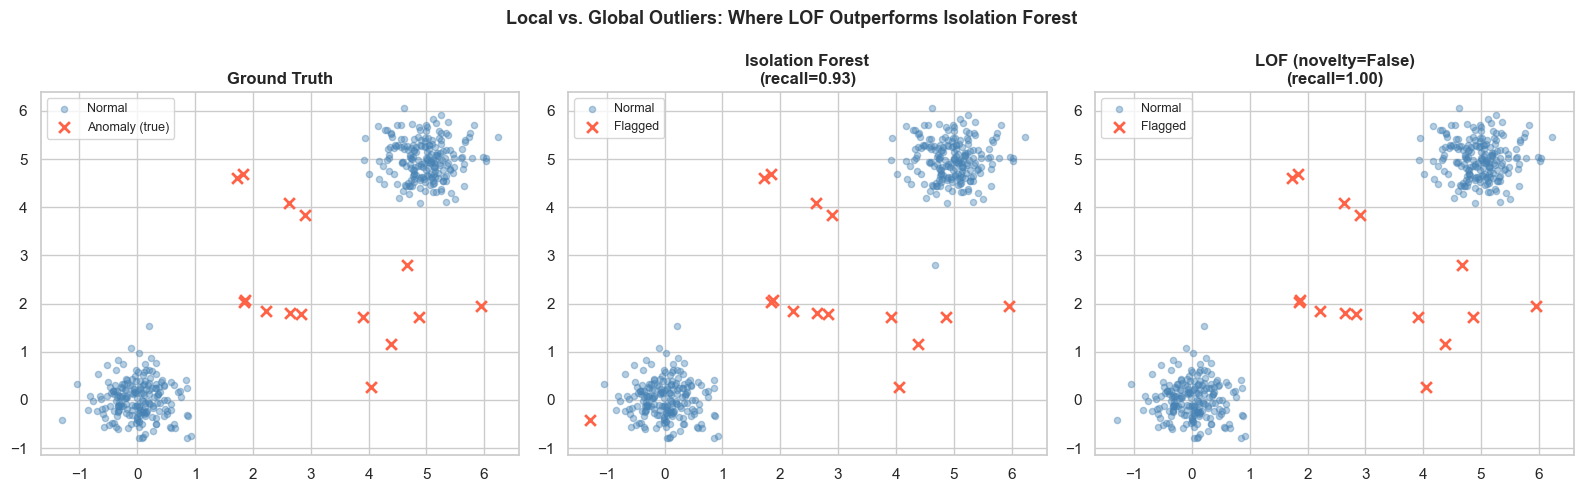

In [10]:
# Create toy data: two dense clusters + one small sparse cluster
np.random.seed(42)

# Dense cluster 1 — main normal group
cluster1 = np.random.randn(200, 2) * 0.4 + np.array([0, 0])
# Dense cluster 2 — secondary normal group
cluster2 = np.random.randn(200, 2) * 0.4 + np.array([5, 5])
# Sparse cluster — anomalies: small group, much less dense, between the two
sparse   = np.random.randn(15, 2)  * 1.5 + np.array([2.5, 2.5])

X_toy = np.vstack([cluster1, cluster2, sparse])
y_toy = np.array([0]*200 + [0]*200 + [1]*15)  # 1 = anomaly

# Fit Isolation Forest on the toy data
iso_toy = IsolationForest(contamination=15/415, random_state=42)
iso_toy_preds = np.where(iso_toy.fit_predict(X_toy) == -1, 1, 0)

# Fit LOF on the toy data (transductive: novelty=False)
lof_toy = LocalOutlierFactor(n_neighbors=20, contamination=15/415)
lof_toy_preds = np.where(lof_toy.fit_predict(X_toy) == -1, 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground truth
axes[0].scatter(X_toy[y_toy==0, 0], X_toy[y_toy==0, 1], c='steelblue', alpha=0.4, s=20, label='Normal')
axes[0].scatter(X_toy[y_toy==1, 0], X_toy[y_toy==1, 1], c='tomato', s=60, marker='x', linewidths=2, label='Anomaly (true)')
axes[0].set_title('Ground Truth', fontweight='bold')
axes[0].legend(fontsize=9)

# Isolation Forest predictions
axes[1].scatter(X_toy[iso_toy_preds==0, 0], X_toy[iso_toy_preds==0, 1], c='steelblue', alpha=0.4, s=20, label='Normal')
axes[1].scatter(X_toy[iso_toy_preds==1, 0], X_toy[iso_toy_preds==1, 1], c='tomato', s=60, marker='x', linewidths=2, label='Flagged')
axes[1].set_title(f'Isolation Forest\n(recall={recall_score(y_toy, iso_toy_preds):.2f})', fontweight='bold')
axes[1].legend(fontsize=9)

# LOF predictions
axes[2].scatter(X_toy[lof_toy_preds==0, 0], X_toy[lof_toy_preds==0, 1], c='steelblue', alpha=0.4, s=20, label='Normal')
axes[2].scatter(X_toy[lof_toy_preds==1, 0], X_toy[lof_toy_preds==1, 1], c='tomato', s=60, marker='x', linewidths=2, label='Flagged')
axes[2].set_title(f'LOF (novelty=False)\n(recall={recall_score(y_toy, lof_toy_preds):.2f})', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Local vs. Global Outliers: Where LOF Outperforms Isolation Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read This Chart: Local vs. Global Outliers

This three-panel chart demonstrates the key difference between global (Isolation Forest) and local (LOF) anomaly detection.

- **Left panel (Ground Truth):** Two large dense clusters of normal points, and a small sparse cluster in the middle (red X marks) — these are the true anomalies.
- **Middle panel (Isolation Forest):** Isolation Forest looks at the global structure. The sparse cluster sits roughly between the two dense clusters, so the points there don't stand out as extremely isolated globally. IsoForest may flag some globally extreme points instead.
- **Right panel (LOF):** LOF looks at local density. The sparse cluster's points are much less dense than their nearest neighbors (who belong to one of the large clusters), so LOF correctly identifies them as local outliers.

**Takeaway:** Use LOF when you expect clusters of different densities and want to catch anomalies that are dense relative to their own sparse neighborhood but might not be globally extreme.

In [11]:
# Train LOF on our main fraud dataset (novelty=True for unseen test data)
t0 = time.time()
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03,
    novelty=True,
    n_jobs=-1
)
lof.fit(X_train_scaled)
t_lof = time.time() - t0

lof_raw_preds = lof.predict(X_test_scaled)
lof_preds = np.where(lof_raw_preds == -1, 1, 0)
lof_scores = lof.decision_function(X_test_scaled)

prec_lof = precision_score(y_test, lof_preds, zero_division=0)
rec_lof  = recall_score(y_test, lof_preds, zero_division=0)
f1_lof   = f1_score(y_test, lof_preds, zero_division=0)
lof_scores_for_pr = -lof_scores
auc_pr_lof = average_precision_score(y_test, lof_scores_for_pr)

print("--- Local Outlier Factor Results ---")
print(f"  Precision : {prec_lof:.4f}")
print(f"  Recall    : {rec_lof:.4f}")
print(f"  F1 Score  : {f1_lof:.4f}")
print(f"  AUC-PR    : {auc_pr_lof:.4f}")
print(f"  Train time: {t_lof:.3f}s")

--- Local Outlier Factor Results ---
  Precision : 0.0861
  Recall    : 0.0878
  F1 Score  : 0.0870
  AUC-PR    : 0.0486
  Train time: 4.027s


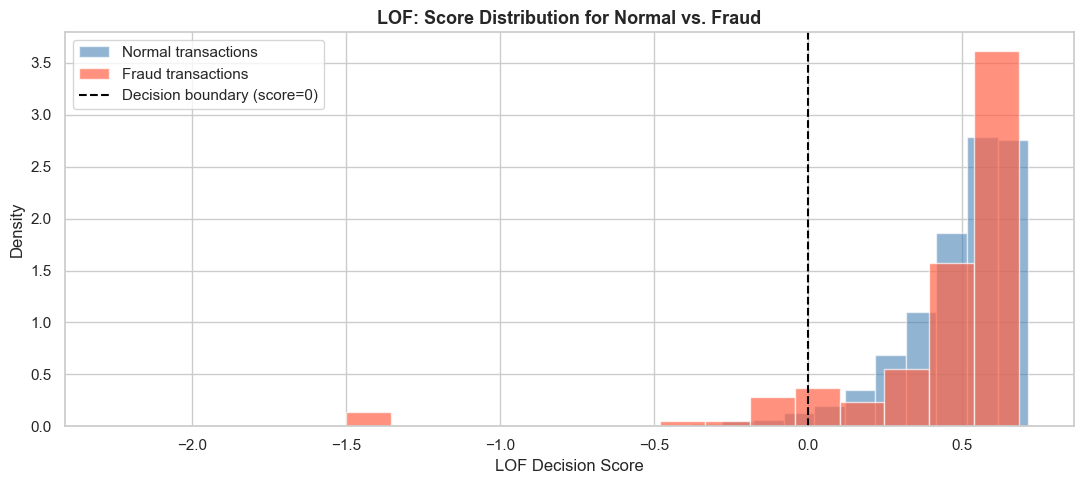

Normal LOF score — mean: 0.4823
Fraud  LOF score — mean: 0.4331


In [12]:
# Plot LOF anomaly scores distribution
fraud_lof_scores  = lof_scores[y_test == 1]
normal_lof_scores = lof_scores[y_test == 0]

plt.figure(figsize=(11, 5))
plt.hist(normal_lof_scores, bins=30, alpha=0.6, color='steelblue', label='Normal transactions', density=True)
plt.hist(fraud_lof_scores,  bins=15, alpha=0.7, color='tomato',    label='Fraud transactions',  density=True)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (score=0)')
plt.xlabel('LOF Decision Score')
plt.ylabel('Density')
plt.title('LOF: Score Distribution for Normal vs. Fraud', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Normal LOF score — mean: {normal_lof_scores.mean():.4f}")
print(f"Fraud  LOF score — mean: {fraud_lof_scores.mean():.4f}")

### How to Read This Chart: LOF Anomaly Scores

This density histogram shows the LOF decision scores for normal vs. fraud transactions.

- **The x-axis** is the LOF decision score. **Negative scores = outlier**, **positive or near-zero scores = normal**. More negative = more anomalous.
- Specifically: a score below 0 means the LOF score is greater than 1 (an outlier); a score above 0 means the LOF score is less than or equal to 1 (normal).
- **Blue distribution** = normal transactions — should peak to the right (positive, near-zero scores).
- **Red distribution** = fraud transactions — should lean toward the left (negative scores).
- **Black dashed line at 0** is the decision threshold.

**Interpreting separation:**
- If the blue and red distributions overlap heavily, LOF struggles to distinguish fraud from normal on this dataset.
- If they separate well, LOF is a strong detector here.
- LOF tends to work best when fraud transactions form a genuinely less-dense local neighborhood compared to their nearest normal neighbors.

---

## Section 6 — One-Class SVM

### The Core Idea

**One-Class SVM** learns a decision boundary around the normal data in a transformed (kernel) feature space. Once trained, any new point that falls **inside** the boundary is considered normal; any point **outside** is flagged as an anomaly.

The RBF (Radial Basis Function) kernel maps the data into a high-dimensional space where normal data forms a compact cluster. The SVM then finds the smallest "bubble" in this space that encloses most of the normal data.

The `nu` parameter controls the upper bound on the fraction of outliers in the training data — similar to `contamination` in Isolation Forest.

---

### When to Use One-Class SVM

- When you have **only normal data** to train on (true novelty detection scenario)
- When the **normal data is compact** and well-clustered in feature space
- When you need a **decision boundary you can visualize or audit**

---

### Important Limitation

> **One-Class SVM is slow on large datasets.** Its training complexity is approximately **O(n²)** in the number of training samples. For datasets with more than ~10,000 samples, prefer Isolation Forest (which trains in O(n log n)). For very large datasets, consider `sklearn.linear_model.SGDOneClassSVM` as a scalable alternative.

In [13]:
# Train One-Class SVM
t0 = time.time()
ocsvm = OneClassSVM(nu=0.03, kernel='rbf', gamma='scale')
ocsvm.fit(X_train_scaled)
t_svm = time.time() - t0

ocsvm_raw_preds = ocsvm.predict(X_test_scaled)
ocsvm_preds = np.where(ocsvm_raw_preds == -1, 1, 0)
ocsvm_scores = ocsvm.decision_function(X_test_scaled)

prec_svm = precision_score(y_test, ocsvm_preds, zero_division=0)
rec_svm  = recall_score(y_test, ocsvm_preds, zero_division=0)
f1_svm   = f1_score(y_test, ocsvm_preds, zero_division=0)
ocsvm_scores_for_pr = -ocsvm_scores
auc_pr_svm = average_precision_score(y_test, ocsvm_scores_for_pr)

print("--- One-Class SVM Results ---")
print(f"  Precision : {prec_svm:.4f}")
print(f"  Recall    : {rec_svm:.4f}")
print(f"  F1 Score  : {f1_svm:.4f}")
print(f"  AUC-PR    : {auc_pr_svm:.4f}")
print(f"  Train time: {t_svm:.3f}s")

--- One-Class SVM Results ---
  Precision : 0.3395
  Recall    : 0.4932
  F1 Score  : 0.4022
  AUC-PR    : 0.2474
  Train time: 0.625s


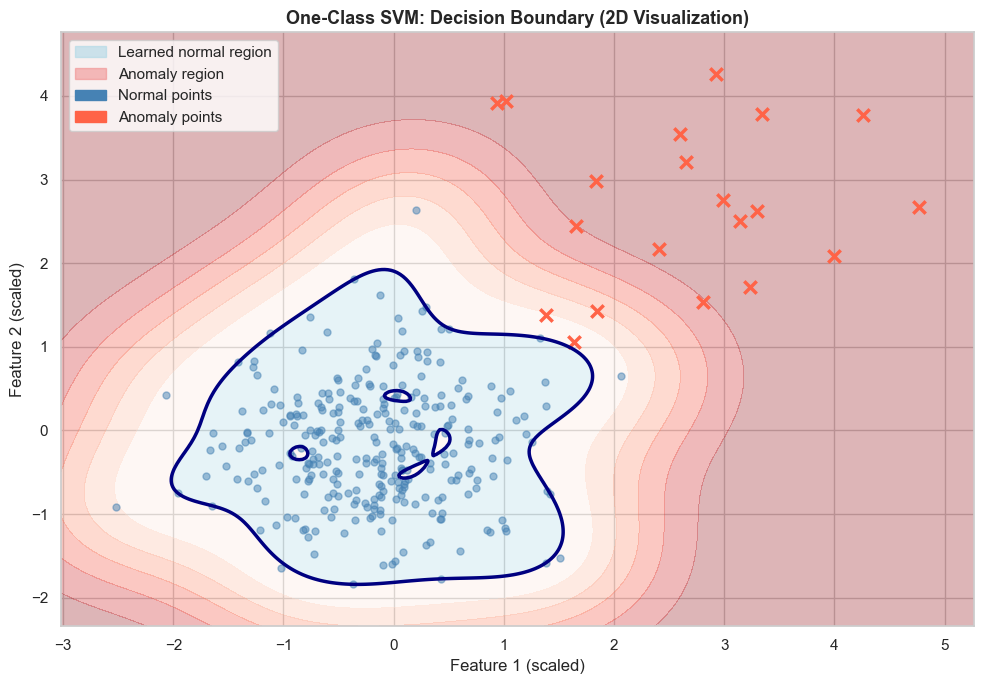

In [14]:
# Visualize decision boundary on 2D synthetic data (2 features only for visibility)
from sklearn.preprocessing import StandardScaler as SS

# Build a clean 2D dataset
np.random.seed(42)
X_norm_2d = np.random.randn(300, 2) * 0.8 + np.array([0, 0])
X_anom_2d = np.random.randn(20, 2)  + np.array([3, 3])
X_2d = np.vstack([X_norm_2d, X_anom_2d])
y_2d = np.array([0]*300 + [1]*20)

scaler_2d = SS()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

ocsvm_2d = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
ocsvm_2d.fit(X_2d_scaled[y_2d == 0])  # Train only on normal class

# Create meshgrid for decision boundary
xx, yy = np.meshgrid(
    np.linspace(X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5, 300),
    np.linspace(X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5, 300)
)
Z = ocsvm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7),
             cmap='Reds_r', alpha=0.3)
plt.contourf(xx, yy, Z, levels=[0, Z.max()],
             colors='lightblue', alpha=0.3)
plt.contour(xx, yy, Z, levels=[0], linewidths=2.5, colors='navy')

plt.scatter(X_2d_scaled[y_2d==0, 0], X_2d_scaled[y_2d==0, 1],
            c='steelblue', alpha=0.5, s=25, label='Normal')
plt.scatter(X_2d_scaled[y_2d==1, 0], X_2d_scaled[y_2d==1, 1],
            c='tomato', s=80, marker='x', linewidths=2.5, label='Anomaly (true)')

# Legend patches
normal_patch = mpatches.Patch(color='lightblue', alpha=0.6, label='Learned normal region')
anomaly_patch = mpatches.Patch(color='lightcoral', alpha=0.5, label='Anomaly region')
plt.legend(handles=[normal_patch, anomaly_patch,
                    mpatches.Patch(color='steelblue', label='Normal points'),
                    mpatches.Patch(color='tomato', label='Anomaly points')],
           loc='upper left')

plt.title('One-Class SVM: Decision Boundary (2D Visualization)', fontsize=13, fontweight='bold')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.tight_layout()
plt.show()

### How to Read This Chart: One-Class SVM Boundary

This plot visualizes the **decision surface** that One-Class SVM has learned, shown in 2D for clarity.

- **Light blue region** = the model's learned "normal" zone. Points falling inside this region are classified as normal.
- **Red-shaded region** = the anomaly zone. Points here are flagged as anomalies.
- **Navy blue contour line** = the exact decision boundary where the score equals zero. Points inside this line = normal, outside = anomaly.
- **Blue dots** = normal training data points. They should cluster inside the boundary.
- **Red X marks** = true anomalies. Ideally they fall outside the blue boundary.

**What the boundary shape tells you:**
- With an RBF kernel, the boundary is always a **smooth closed curve** (or multiple curves) shaped by the density of normal training data.
- Where normal data is dense, the boundary bulges outward. Where normal data is sparse, the boundary pulls inward.
- If `nu` is very small, the boundary is very tight and may exclude some real normal points. If `nu` is too large, it expands to include anomalies.

> **Note:** This visualization uses a 2D synthetic toy dataset for illustration. In the real 10-dimensional fraud dataset, the boundary exists in a much higher-dimensional space and cannot be directly plotted.

---

## Section 6.5 — Two More Detectors: Elliptic Envelope & Novelty-Mode LOF

Before the autoencoder, two quick additions round out the classical toolkit:

- **Elliptic Envelope** assumes the normal data follows a single multivariate **Gaussian** and fits a robust
  covariance ellipse around it; points far outside the ellipse (by Mahalanobis distance) are anomalies. It's
  the natural *statistical* baseline — fast and interpretable, but it fails when normal data is multi-modal.
- **Novelty-mode LOF** flips LOF's usual role. In Section 5 we ran LOF in *outlier-detection* mode (fit and
  score the same data). With `novelty=True`, we instead **fit on clean/normal data only**, then score brand-new
  points — the same train-on-normal / score-new pattern the autoencoder uses. This is how you'd actually deploy
  LOF in production.


In [15]:
from sklearn.covariance import EllipticEnvelope

# --- Elliptic Envelope: robust Gaussian ellipse around the data ---
ee = EllipticEnvelope(contamination=0.03, random_state=RANDOM_STATE, support_fraction=0.9)
ee.fit(X_train_scaled)
ee_preds  = np.where(ee.predict(X_test_scaled) == -1, 1, 0)
ee_scores = -ee.decision_function(X_test_scaled)   # higher = more anomalous

# --- Novelty-mode LOF: fit on NORMAL training data only, score the test set ---
X_train_normal = X_train_scaled[y_train == 0]
lof_nov = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.03)
lof_nov.fit(X_train_normal)
lofn_preds  = np.where(lof_nov.predict(X_test_scaled) == -1, 1, 0)
lofn_scores = -lof_nov.score_samples(X_test_scaled)  # higher = more anomalous

for name, preds, scores in [('Elliptic Envelope', ee_preds, ee_scores),
                            ('LOF (novelty=True)', lofn_preds, lofn_scores)]:
    print(f"--- {name} ---")
    print(f"  Precision : {precision_score(y_test, preds, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_test, preds, zero_division=0):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, preds, zero_division=0):.4f}")
    print(f"  AUC-PR    : {average_precision_score(y_test, scores):.4f}")
    print()


--- Elliptic Envelope ---
  Precision : 0.5988
  Recall    : 0.6757
  F1 Score  : 0.6349
  AUC-PR    : 0.5660

--- LOF (novelty=True) ---
  Precision : 0.4420
  Recall    : 0.8243
  F1 Score  : 0.5755
  AUC-PR    : 0.8084



### How to Read These Results

Compare their **AUC-PR** (the imbalance-aware metric, explained in Section 9) against Isolation Forest and LOF:

- **Elliptic Envelope** often does *worse* here than Isolation Forest. That's the lesson, not a bug: the `V1`–`V28`
  features are PCA components and the normal class isn't a single clean Gaussian blob, so the ellipse assumption
  is only roughly right. Elliptic Envelope shines when normal data really is unimodal and roughly Gaussian.
- **Novelty-mode LOF** typically tracks or beats plain LOF, because training on *clean* data gives it a cleaner
  notion of "normal density" — but it needs a trustworthy normal-only training set, which you don't always have.

> **Takeaway:** there's no universally best detector. The right choice depends on the *shape* of your normal data
> (unimodal vs. multi-modal), whether you have clean training data, and your compute budget.


---

## Section 7 — Autoencoder-Based Anomaly Detection

### The Core Idea

An **Autoencoder** is a neural network trained to **reconstruct its own input**. It does this by compressing the input into a small bottleneck (the encoder), then expanding it back to the original size (the decoder).

```
Input (10 features)
       │
  ┌────▼────┐
  │  Dense  │  10 → 8      ← Encoder starts
  │  ReLU   │
  └────┬────┘
       │
  ┌────▼────┐
  │  Dense  │  8 → 4       ← Bottleneck (compressed representation)
  │  ReLU   │
  └────┬────┘
       │
  ┌────▼────┐
  │  Dense  │  4 → 8       ← Decoder starts
  │  ReLU   │
  └────┬────┘
       │
  ┌────▼────┐
  │  Dense  │  8 → 10      ← Output (reconstructed input)
  └────┬────┘
       │
 Reconstruction Error = MSE(Input, Output)
```

### Why This Works for Anomaly Detection

We train the autoencoder **only on normal transactions**. After training, the model becomes very good at reconstructing normal patterns — it has essentially memorized what "normal" looks like.

At inference time:
- **Normal transactions:** The autoencoder reconstructs them well → **low reconstruction error**.
- **Fraud transactions:** The autoencoder has never seen these patterns → it struggles to reconstruct them → **high reconstruction error**.

We set a **threshold** on the reconstruction error: points above the threshold are flagged as anomalies.

---

### Architecture: Linear 10 → 8 → 4 → 8 → 10

In [16]:
# Define the Autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim=29):
        super(Autoencoder, self).__init__()

        # Encoder: compresses input to bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        # Decoder: reconstructs input from bottleneck
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Verify architecture
model = Autoencoder(input_dim=n_features)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=29, bias=True)
  )
)

Total trainable parameters: 1,253


In [17]:
# Prepare training data — use ONLY normal class samples
normal_mask_train = y_train == 0
X_train_normal = X_train_scaled[normal_mask_train]

print(f"Training autoencoder on {X_train_normal.shape[0]} normal samples only")
print(f"(Withholding {normal_mask_train.sum()} normal + {(~normal_mask_train).sum()} fraud from training)")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_normal)
train_dataset  = TensorDataset(X_train_tensor)
train_loader   = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Initialize model, optimizer, loss
ae_model   = Autoencoder(input_dim=n_features)
optimizer  = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
criterion  = nn.MSELoss()
device     = torch.device('cpu')
ae_model.to(device)

# Training loop
t0 = time.time()
num_epochs = 40
train_losses = []

ae_model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        x_recon = ae_model(x)
        loss = criterion(x_recon, x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    avg_loss = epoch_loss / len(X_train_normal)
    train_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch [{epoch+1:3d}/{num_epochs}]  Loss: {avg_loss:.6f}")

t_ae = time.time() - t0
print(f"\nTraining complete in {t_ae:.2f}s")

Training autoencoder on 11200 normal samples only
(Withholding 11200 normal + 344 fraud from training)


  Epoch [ 20/40]  Loss: 0.383800


  Epoch [ 40/40]  Loss: 0.342758

Training complete in 13.35s


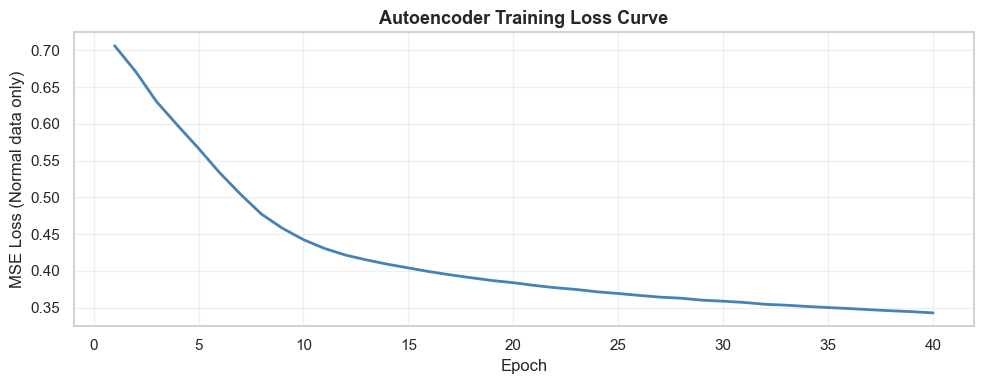

In [18]:
# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, num_epochs + 1), train_losses, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (Normal data only)')
plt.title('Autoencoder Training Loss Curve', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Normal recon error  — mean: 0.386313,  std: 1.127482
Fraud  recon error  — mean: 10.823074,  std: 13.699847


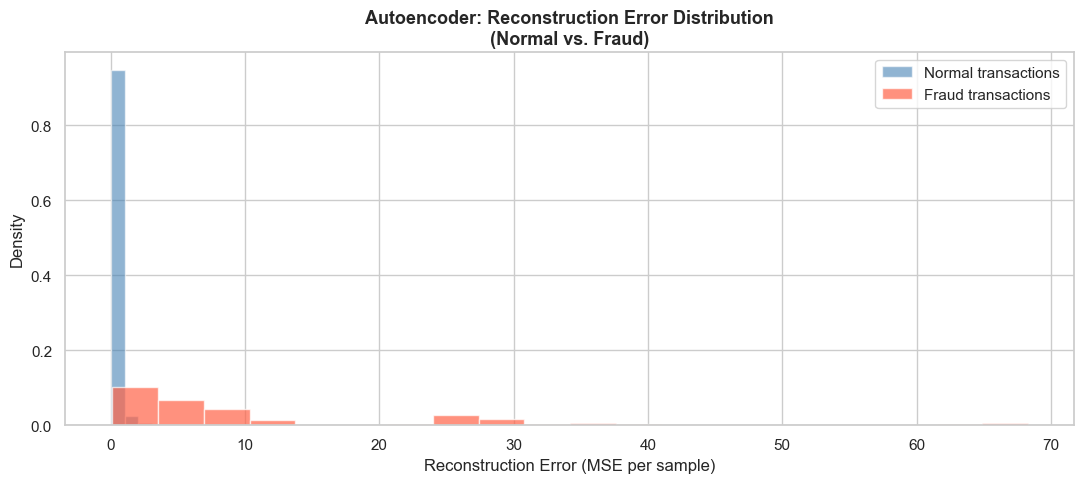

In [19]:
# Compute reconstruction error on the TEST set
ae_model.eval()
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

with torch.no_grad():
    X_test_recon = ae_model(X_test_tensor)

# Per-sample MSE reconstruction error
recon_errors = ((X_test_tensor - X_test_recon) ** 2).mean(dim=1).cpu().numpy()

fraud_recon  = recon_errors[y_test == 1]
normal_recon = recon_errors[y_test == 0]

print(f"Normal recon error  — mean: {normal_recon.mean():.6f},  std: {normal_recon.std():.6f}")
print(f"Fraud  recon error  — mean: {fraud_recon.mean():.6f},  std: {fraud_recon.std():.6f}")

# Plot reconstruction error distribution
plt.figure(figsize=(11, 5))
plt.hist(normal_recon, bins=40, alpha=0.6, color='steelblue', label='Normal transactions', density=True)
plt.hist(fraud_recon,  bins=20, alpha=0.7, color='tomato',    label='Fraud transactions',  density=True)
plt.xlabel('Reconstruction Error (MSE per sample)')
plt.ylabel('Density')
plt.title('Autoencoder: Reconstruction Error Distribution\n(Normal vs. Fraud)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### How to Read This Chart: Reconstruction Error Distribution

This histogram shows the reconstruction error (MSE) for each test sample, split by true class.

- **The x-axis** is the reconstruction error. **Higher error = more anomalous.** The model learned normal patterns, so it reconstructs normal data well (low error) and struggles with fraud (high error).
- **Blue distribution (Normal):** Should peak to the **left** (low error) — the model was trained on this data and knows how to reconstruct it.
- **Red distribution (Fraud):** Should lean to the **right** (high error) — these patterns were never seen during training, so the bottleneck can't compress them efficiently, and reconstruction is poor.

**What good separation looks like:**
- The blue peak and the red peak are far apart on the x-axis.
- There is a gap or transition zone between them — this is where you'd set the threshold.
- If the two distributions overlap heavily, the autoencoder doesn't distinguish fraud well on this dataset.

> **Key insight:** The autoencoder's power comes from the fact that it was trained **only on normal data**. The bottleneck layer forces it to learn a compressed "normal fingerprint." Anything that deviates from this fingerprint generates high reconstruction error.

---

## Section 8 — Threshold Selection for Autoencoder

### The Threshold Trade-off

The reconstruction error is a **continuous score** — we need to pick a **threshold** to convert it into a binary prediction (fraud vs. normal).

The choice of threshold directly controls the precision-recall trade-off:

| Threshold Direction | Effect on Recall | Effect on Precision | Business Implication |
|--------------------|-----------------|--------------------|---------------------|
| **Move threshold LEFT** (lower) | ↑ Higher recall | ↓ Lower precision | More frauds caught, but more false alarms sent to the fraud review team |
| **Move threshold RIGHT** (higher) | ↓ Lower recall | ↑ Higher precision | Fewer false alarms, but some real frauds slip through undetected |

**In fraud detection, missing a fraud is usually more expensive than a false alarm** — so we often prefer higher recall, even at the cost of some precision. The exact optimal threshold depends on your business context.

> **Rule of thumb:** Set the threshold at the **95th percentile of reconstruction error on normal validation data**. This means 5% of normal transactions will be flagged as false positives, but you'll catch most frauds.

In [20]:
# Choose threshold: 95th percentile of normal errors
threshold = np.percentile(normal_recon, 95)
print(f"Threshold (95th pct of normal errors): {threshold:.6f}")

ae_preds = (recon_errors > threshold).astype(int)

prec_ae = precision_score(y_test, ae_preds, zero_division=0)
rec_ae  = recall_score(y_test, ae_preds, zero_division=0)
f1_ae   = f1_score(y_test, ae_preds, zero_division=0)
auc_pr_ae = average_precision_score(y_test, recon_errors)

print(f"\n--- Autoencoder Results (threshold={threshold:.4f}) ---")
print(f"  Precision : {prec_ae:.4f}")
print(f"  Recall    : {rec_ae:.4f}")
print(f"  F1 Score  : {f1_ae:.4f}")
print(f"  AUC-PR    : {auc_pr_ae:.4f}")
print(f"  Train time: {t_ae:.3f}s")

Threshold (95th pct of normal errors): 0.899118

--- Autoencoder Results (threshold=0.8991) ---
  Precision : 0.3460
  Recall    : 0.8581
  F1 Score  : 0.4932
  AUC-PR    : 0.6596
  Train time: 13.355s


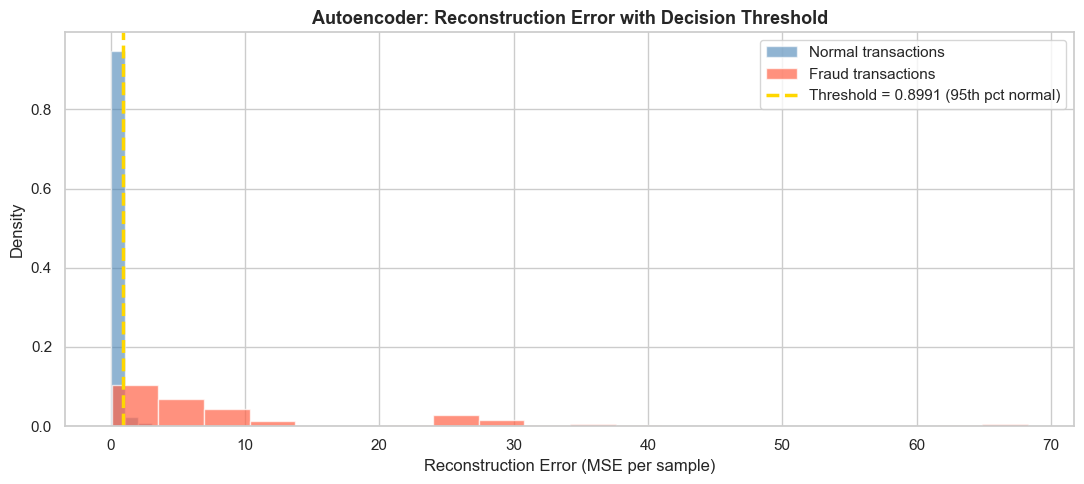

In [21]:
# Plot reconstruction error distribution with threshold line
plt.figure(figsize=(11, 5))
plt.hist(normal_recon, bins=40, alpha=0.6, color='steelblue', label='Normal transactions', density=True)
plt.hist(fraud_recon,  bins=20, alpha=0.7, color='tomato',    label='Fraud transactions',  density=True)
plt.axvline(x=threshold, color='gold', linewidth=2.5, linestyle='--',
            label=f'Threshold = {threshold:.4f} (95th pct normal)')
plt.xlabel('Reconstruction Error (MSE per sample)')
plt.ylabel('Density')
plt.title('Autoencoder: Reconstruction Error with Decision Threshold', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

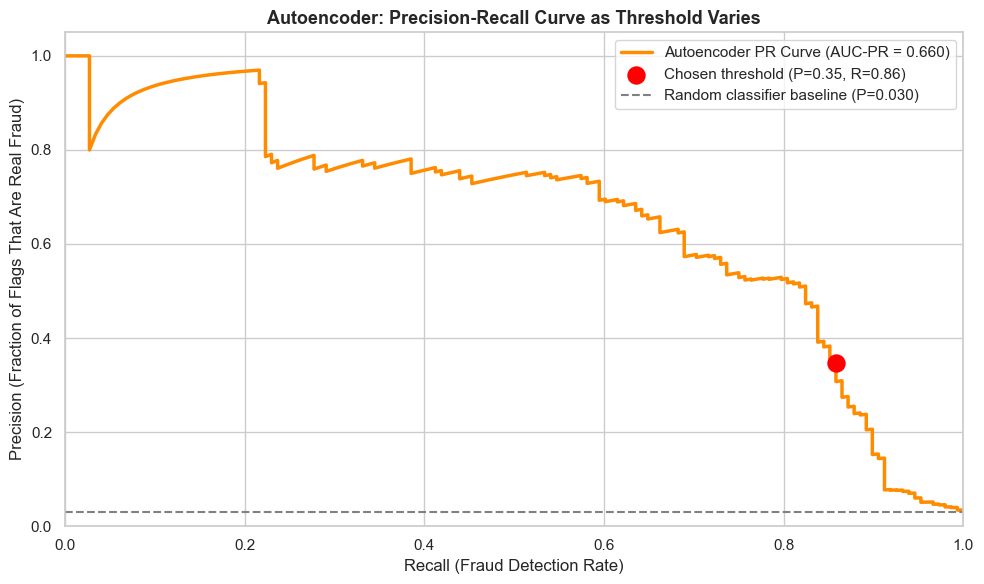

In [22]:
# Plot Precision-Recall curve as threshold varies
precision_curve, recall_curve, threshold_vals = precision_recall_curve(y_test, recon_errors)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='darkorange', linewidth=2.5,
         label=f'Autoencoder PR Curve (AUC-PR = {auc_pr_ae:.3f})')

# Mark the chosen threshold
chosen_prec = prec_ae
chosen_rec  = rec_ae
plt.scatter([chosen_rec], [chosen_prec], color='red', s=150, zorder=5,
            label=f'Chosen threshold (P={chosen_prec:.2f}, R={chosen_rec:.2f})')

# Baseline: random classifier
fraud_rate = y_test.mean()
plt.axhline(y=fraud_rate, color='gray', linestyle='--', linewidth=1.5,
            label=f'Random classifier baseline (P={fraud_rate:.3f})')

plt.xlabel('Recall (Fraud Detection Rate)', fontsize=12)
plt.ylabel('Precision (Fraction of Flags That Are Real Fraud)', fontsize=12)
plt.title('Autoencoder: Precision-Recall Curve as Threshold Varies', fontsize=13, fontweight='bold')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

### How to Read This Chart: Threshold Selection

This chart shows the **Precision-Recall (PR) curve** for the Autoencoder. Every point on the curve corresponds to a different threshold applied to the reconstruction error.

- **The x-axis (Recall):** What fraction of all true frauds the model catches. Recall = 1.0 means every fraud is detected. Recall = 0.0 means none are detected.
- **The y-axis (Precision):** Of the transactions the model flags as fraud, what fraction really are fraud. Precision = 1.0 means every flag is correct. Precision = 0.0 means every flag is a false alarm.
- **Moving along the curve from upper-left to lower-right** corresponds to **lowering the threshold** — catching more frauds (higher recall) but generating more false positives (lower precision).
- **The red dot** marks our chosen threshold (95th percentile of normal error).
- **The gray dashed line** is the random classifier baseline — a classifier that randomly flags transactions at the fraud rate would have precision = fraud rate (about 3%). Any useful model must be well above this line.

**Business guidance:**
- In **fraud detection:** Prefer the upper-right of the curve (high precision AND high recall). Since missing fraud is costly, lean toward higher recall, accepting some precision loss.
- In **medical diagnosis:** Same logic — missing a true case is worse than a false alarm.
- In **spam filtering:** Missing a real email (false positive) may be worse, so lean toward higher precision.
- **The Area Under the PR Curve (AUC-PR)** is a single number summarizing overall model quality. Higher is better. A random classifier has AUC-PR = fraud rate ≈ 0.03.

---

## Section 9 — Final Comparison: All 4 Methods

### Head-to-Head Evaluation

Now we bring everything together. We evaluate all four methods on the same dataset and test set, and compare them across five dimensions:
1. **Precision** — accuracy of fraud flags
2. **Recall** — fraud detection rate
3. **F1 Score** — balanced measure
4. **AUC-PR** — area under the precision-recall curve (the right metric for imbalanced data)
5. **Training Time** — practical scalability

### Why NOT AUC-ROC for Anomaly Detection?

You might be used to seeing **ROC-AUC** (Area Under the ROC Curve) reported for classification problems. For anomaly detection with extreme class imbalance, **ROC-AUC is misleading and overly optimistic**.

Here's why:

- **ROC curve** plots True Positive Rate vs. False Positive Rate. With only 3% fraud, even a mediocre model achieves a low False Positive Rate easily (because the denominator — total negatives — is huge). This makes the ROC curve look great even when the model is actually missing most frauds.
- **PR curve** plots Precision vs. Recall. These metrics focus entirely on the minority (fraud) class. A model must be genuinely good at catching fraud to achieve a high AUC-PR.
- **Random classifier ROC-AUC = 0.5** regardless of class balance — this is deceptively reassuring.
- **Random classifier AUC-PR = fraud rate** (≈ 0.03 here) — this is brutally honest about how hard the problem is.

> **Always use AUC-PR for anomaly detection and highly imbalanced classification.**

In [23]:
# Compile all results into a comparison table
comparison_data = {
    'Method': [
        'Isolation Forest',
        'Local Outlier Factor',
        'One-Class SVM',
        'Autoencoder'
    ],
    'Precision': [prec_iso, prec_lof, prec_svm, prec_ae],
    'Recall':    [rec_iso,  rec_lof,  rec_svm,  rec_ae],
    'F1 Score':  [f1_iso,   f1_lof,   f1_svm,   f1_ae],
    'AUC-PR':    [auc_pr_iso, auc_pr_lof, auc_pr_svm, auc_pr_ae],
    'Train Time (s)': [round(t_iso, 3), round(t_lof, 3), round(t_svm, 3), round(t_ae, 3)]
}

comparison_df = pd.DataFrame(comparison_data).set_index('Method')

print("=" * 70)
print(" Final Comparison: All 4 Anomaly Detection Methods")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)

fraud_rate_test = y_test.mean()
print(f"\nBaseline AUC-PR (random classifier) ≈ {fraud_rate_test:.4f}")
print(f"Baseline ROC-AUC (random classifier) = 0.5000")

 Final Comparison: All 4 Anomaly Detection Methods
                      Precision  Recall  F1 Score  AUC-PR  Train Time (s)
Method                                                                   
Isolation Forest         0.5763  0.6892    0.6277  0.6721          0.6810
Local Outlier Factor     0.0861  0.0878    0.0870  0.0486          4.0270
One-Class SVM            0.3395  0.4932    0.4022  0.2474          0.6250
Autoencoder              0.3460  0.8581    0.4932  0.6596         13.3550

Baseline AUC-PR (random classifier) ≈ 0.0299
Baseline ROC-AUC (random classifier) = 0.5000


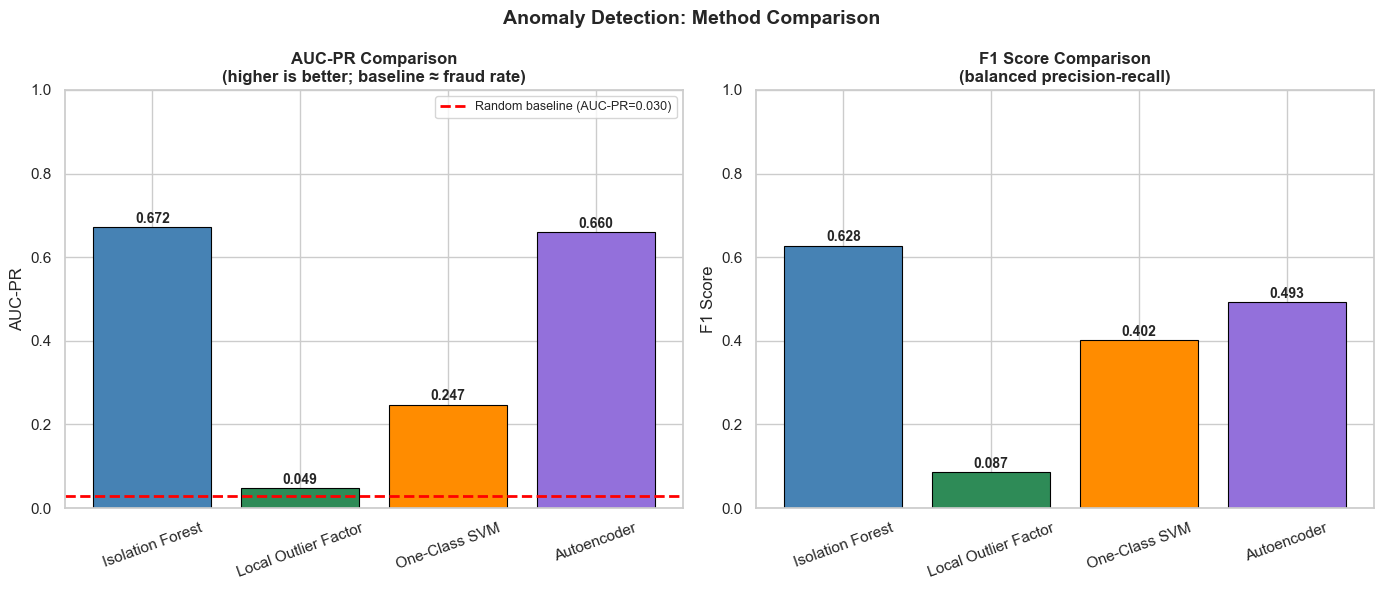

In [24]:
# Bar chart of AUC-PR for all 4 methods
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_methods = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

# AUC-PR bar chart
bars = axes[0].bar(
    comparison_df.index,
    comparison_df['AUC-PR'],
    color=colors_methods,
    edgecolor='black',
    linewidth=0.8
)
axes[0].axhline(y=fraud_rate_test, color='red', linestyle='--', linewidth=2,
                label=f'Random baseline (AUC-PR={fraud_rate_test:.3f})')
axes[0].set_title('AUC-PR Comparison\n(higher is better; baseline ≈ fraud rate)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AUC-PR')
axes[0].set_ylim([0, 1.0])
axes[0].legend(fontsize=9)
for bar, val in zip(bars, comparison_df['AUC-PR']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# F1 Score bar chart
bars2 = axes[1].bar(
    comparison_df.index,
    comparison_df['F1 Score'],
    color=colors_methods,
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_title('F1 Score Comparison\n(balanced precision-recall)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim([0, 1.0])
for bar, val in zip(bars2, comparison_df['F1 Score']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Anomaly Detection: Method Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

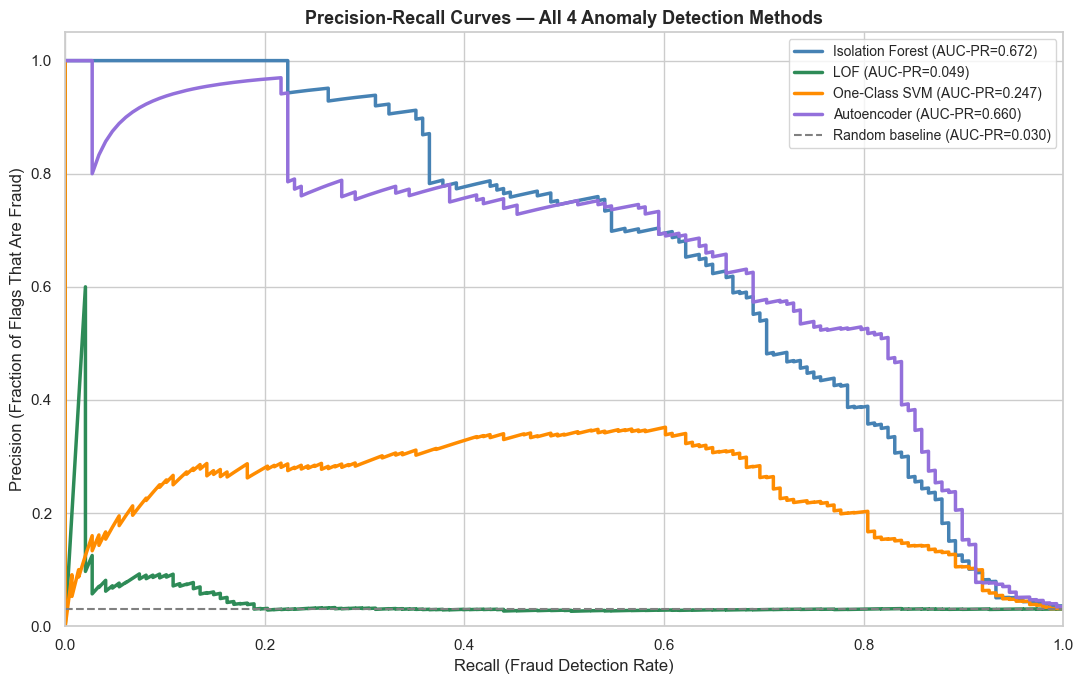

In [25]:
# Precision-Recall curves for all 4 methods on same axes
plt.figure(figsize=(11, 7))

# Isolation Forest PR curve
prec_curve_iso, rec_curve_iso, _ = precision_recall_curve(y_test, iso_scores_for_pr)
plt.plot(rec_curve_iso, prec_curve_iso,
         color='steelblue', linewidth=2.5,
         label=f'Isolation Forest (AUC-PR={auc_pr_iso:.3f})')

# LOF PR curve
prec_curve_lof, rec_curve_lof, _ = precision_recall_curve(y_test, lof_scores_for_pr)
plt.plot(rec_curve_lof, prec_curve_lof,
         color='seagreen', linewidth=2.5,
         label=f'LOF (AUC-PR={auc_pr_lof:.3f})')

# One-Class SVM PR curve
prec_curve_svm, rec_curve_svm, _ = precision_recall_curve(y_test, ocsvm_scores_for_pr)
plt.plot(rec_curve_svm, prec_curve_svm,
         color='darkorange', linewidth=2.5,
         label=f'One-Class SVM (AUC-PR={auc_pr_svm:.3f})')

# Autoencoder PR curve
prec_curve_ae, rec_curve_ae, _ = precision_recall_curve(y_test, recon_errors)
plt.plot(rec_curve_ae, prec_curve_ae,
         color='mediumpurple', linewidth=2.5,
         label=f'Autoencoder (AUC-PR={auc_pr_ae:.3f})')

# Random classifier baseline
plt.axhline(y=fraud_rate_test, color='gray', linestyle='--', linewidth=1.5,
            label=f'Random baseline (AUC-PR={fraud_rate_test:.3f})')

plt.xlabel('Recall (Fraud Detection Rate)', fontsize=12)
plt.ylabel('Precision (Fraction of Flags That Are Fraud)', fontsize=12)
plt.title('Precision-Recall Curves — All 4 Anomaly Detection Methods', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

### How to Read This Chart: Precision-Recall Curves for Anomaly Detection

This is the most important chart in the notebook — it compares all four methods on equal footing.

**How to read a PR curve:**
- **x-axis = Recall:** Moving right means catching more real frauds.
- **y-axis = Precision:** Moving up means fewer false alarms.
- **Ideal model:** A curve that hugs the **upper-right corner** — high precision AND high recall simultaneously.
- **Each point on a curve** corresponds to a specific threshold. Moving along the curve from right to left = raising the threshold = more conservative flagging.

**Why PR curves, not ROC curves?**
- With only 3% fraud, the True Negative Rate (a component of ROC) is trivially high — there are 32 normal transactions for every fraud. Even a weak model rarely flags normal transactions as fraud simply due to the math. This inflates ROC-AUC and hides poor performance.
- PR curves use only Precision and Recall — both computed entirely on the fraud class. They ruthlessly expose how good you really are at catching fraud.
- **The random classifier baseline on a PR curve = fraud rate ≈ 0.03** — brutally low, showing just how hard the problem is.
- **The random classifier baseline on a ROC curve = 0.5** — a deceptive midpoint that makes even useless models look "halfway decent."

> **Summary:** Always use AUC-PR when evaluating anomaly detection or imbalanced classification. It tells you what you actually need to know: can this model catch fraud efficiently?

---

## Section 10 — Summary and Key Takeaways

### Algorithm Selection Guide

| Method | When to Use | Speed | Memory | Online/Offline | Key Hyperparameter |
|--------|------------|-------|--------|---------------|--------------------|
| **Isolation Forest** | Large datasets, high dimensions, general-purpose anomaly detection | ⚡ Fast — O(n log n) | Low | Offline (batch) | `contamination` (assumed anomaly rate) |
| **LOF** | Small-to-medium datasets, clusters of varying density, local outliers | 🐢 Slow — O(n²) | Medium | Offline (transductive) or Novelty mode | `n_neighbors` (neighborhood size) |
| **One-Class SVM** | Compact normal class, need boundary visualization, small-to-medium data | 🐢 Slow — O(n²) | Medium | Offline (batch) | `nu` (upper bound on outlier fraction), `kernel` |
| **Autoencoder** | You have abundant normal training data, high-dimensional or complex data, neural pipeline | ⏱️ Medium (GPU helps) | Higher | Offline (retrain periodically) | Architecture depth, threshold percentile |

---

### Decision Guide: Which Method Should I Use?

```
START HERE
    │
    ▼
Dataset has > 100,000 samples?
    │ YES                        │ NO
    ▼                            ▼
Use Isolation Forest     Do you have abundant 
(scales to millions)     LABELED normal data?
                              │ YES              │ NO
                              ▼                  ▼
                        Use Autoencoder     Do you need local
                        (train on normal    outlier detection?
                         data only;         │ YES        │ NO
                         great for high     ▼            ▼
                         dim data)         Use LOF    Use Isolation
                                           (catches   Forest or
                                            local     One-Class SVM
                                            anomalies)
```

> **When in doubt, start with Isolation Forest.** It's fast, robust, parameter-light, and works well in most scenarios.

---

### Key Takeaways

1. **Always use AUC-PR, not AUC-ROC** for anomaly detection. ROC-AUC is optimistic on imbalanced data. AUC-PR honestly reflects performance on the rare class that actually matters.

2. **Contamination matters** — Setting the contamination parameter (Isolation Forest) or `nu` (One-Class SVM) to match the true anomaly rate in your domain is crucial. Start with your domain knowledge, then tune with a labeled validation set.

3. **Autoencoders need normal data** — The autoencoder approach is powerful but requires that your training data is predominantly or entirely normal. If training data is contaminated with unknown anomalies, the model will learn to reconstruct them too.

4. **LOF is powerful but slow** — LOF's local density approach catches anomaly types that global methods miss, but it doesn't scale to large datasets. Use it when you have time and your dataset is under ~50,000 samples.

5. **Threshold is a business decision** — For all these methods, the final binary cutoff ("flag as fraud or not") involves a precision-recall trade-off that depends on your business costs: the cost of a missed fraud vs. the cost of a false alarm.

---

### Common Mistakes to Avoid

| Mistake | Why It's Wrong | What to Do Instead |
|---------|---------------|--------------------|
| **Using accuracy as the metric** | With 97% normal data, always predicting "normal" gives 97% accuracy — completely useless | Use Precision, Recall, F1, and AUC-PR |
| **Not tuning contamination** | Default values may be far from your true anomaly rate, giving poor precision or recall | Set contamination to your domain estimate, tune with a labeled validation set |
| **Training autoencoder on mixed data** | If fraud is in the training set, the autoencoder learns to reconstruct fraud too — you lose the reconstruction error signal | Train only on confirmed normal data |
| **Using ROC-AUC on imbalanced data** | ROC-AUC is inflated and misleading when negatives vastly outnumber positives | Use AUC-PR instead |
| **Skipping feature scaling** | LOF and One-Class SVM are sensitive to feature scale — unscaled features dominate distance calculations | Always scale features before LOF, SVM, and Autoencoder |
| **Evaluating on the training set** | Isolation Forest and LOF (non-novelty mode) can trivially "find" anomalies it already saw | Always evaluate on a held-out test set |

---

### What's Next?

If you want to go further with anomaly detection:

- **Extended Isolation Forest** — a variant that fixes directional bias in standard Isolation Forest
- **DBSCAN** — density-based clustering that naturally labels sparse-region points as outliers
- **Variational Autoencoders (VAE)** — a probabilistic extension that provides uncertainty estimates alongside reconstruction error
- **Time-series anomaly detection** — LSTM autoencoders or Prophet for detecting anomalies in sequential/temporal data
- **Ensemble approaches** — averaging scores from multiple detectors often outperforms any single method

---

### Final Metrics Summary

In [26]:
# Final styled summary table
print("\n" + "=" * 75)
print(" FINAL SUMMARY: Anomaly Detection Method Comparison")
print("=" * 75)
print(f"{'Method':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-PR':>10} {'Time(s)':>10}")
print("-" * 75)

methods   = ['Isolation Forest', 'LOF', 'One-Class SVM', 'Autoencoder']
precisions = [prec_iso, prec_lof, prec_svm, prec_ae]
recalls    = [rec_iso,  rec_lof,  rec_svm,  rec_ae]
f1s        = [f1_iso,   f1_lof,   f1_svm,   f1_ae]
aucprs     = [auc_pr_iso, auc_pr_lof, auc_pr_svm, auc_pr_ae]
times      = [t_iso, t_lof, t_svm, t_ae]

for m, p, r, f, a, t in zip(methods, precisions, recalls, f1s, aucprs, times):
    print(f"{m:<25} {p:>10.4f} {r:>10.4f} {f:>10.4f} {a:>10.4f} {t:>10.3f}")

print("-" * 75)
print(f"{'Random Baseline':<25} {'---':>10} {'---':>10} {'---':>10} {fraud_rate_test:>10.4f} {'---':>10}")
print("=" * 75)
print(f"\nFraud rate in test set: {fraud_rate_test*100:.2f}%")
print("Best practice metric for imbalanced anomaly detection: AUC-PR")
print("All methods trained UNSUPERVISED — no fraud labels used during fitting.")


 FINAL SUMMARY: Anomaly Detection Method Comparison
Method                     Precision     Recall         F1     AUC-PR    Time(s)
---------------------------------------------------------------------------
Isolation Forest              0.5763     0.6892     0.6277     0.6721      0.681
LOF                           0.0861     0.0878     0.0870     0.0486      4.027
One-Class SVM                 0.3395     0.4932     0.4022     0.2474      0.625
Autoencoder                   0.3460     0.8581     0.4932     0.6596     13.355
---------------------------------------------------------------------------
Random Baseline                  ---        ---        ---     0.0299        ---

Fraud rate in test set: 2.99%
Best practice metric for imbalanced anomaly detection: AUC-PR
All methods trained UNSUPERVISED — no fraud labels used during fitting.
